# Where a trading idea meets the data — cross-asset momentum EDA

**Docker image**: `ml4t`

**Purpose**: Before we freeze a setup or fit a model, we test whether one concrete
idea — **cross-asset momentum** on the 100-ETF universe — actually leaves a
footprint in the data. This is the exploratory step that sits between a *story*
("what rose recently keeps rising") and a *strategy*. We use the single most
informative EDA tool in this domain: **sort by the signal, then look at forward
returns per bucket.**

## The idea and its mechanism

The idea: assets that went up over the past year tend to keep earning more than the
rest of the universe over the next month, *across* asset classes (equities, sectors, countries, bonds,
commodities). Before any statistics, name the mechanism — *who is on the other
side, and why are they happy to trade with us?* This idea sits in the "behind"
family: we are betting others are slow or a step behind, not that we are paid to
bear a risk.

- **SLOW**: macro information diffuses across siloed markets with a lag; capital
  moves to the trend slowly. That gradual adjustment *is* the return.
- **WRONG**: investors under-react to news and chase performance, extending trends
  past fundamentals.

So this is a SLOW/WRONG blend. That also tells us the failure mode in advance:
momentum reverses sharply at turning points, and — because everyone can read the
same price history — the edge is the kind that **decays**. Keep that hypothesis in
mind; the data will have something to say about it.

## Learning objectives

- Build a monthly cross-sectional panel from the ETF daily data.
- Construct the classic **12-1 month momentum** signal (skip the most recent month).
- Run the **quintile conditional-return sort** and read it for *monotonicity,
  magnitude, and shape*.
- Stress the result by **era** — the difference between a footprint and an artifact.
- Leave with a measured reading that motivates the rest of the chapter: freeze the
  setup, validate walk-forward, and respect costs and effective sample size.

**Book reference**: Chapter 6 §6.1–§6.2 (from idea to evidence; mapping strategies
and sources of edge); Chapter 7 (defining a tradable label and the conditional
feature–label relationship).

**Prerequisites**: `data` package on `PYTHONPATH`; ETF parquet present at
`ML4T_DATA_PATH/etfs/market/`. Run `python data/etfs/market/download.py` if missing.

In [1]:
"""Cross-asset momentum EDA — from a story to a measured footprint."""

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from data import load_etfs
from utils.style import COLORS, add_message_title, show_with_alt

In [2]:
# Production defaults — Papermill injects overrides for CI
LOOKBACK = 12  # months of past return in the signal
SKIP = 1  # skip the most recent month (the "12-1" convention)
N_QUANTILES = 5  # quintiles
MIN_NAMES = 30  # minimum eligible ETFs in a month to include it

## 1. Build the monthly panel

The signal and the outcome both live at a **monthly** cadence: we rank the
universe once a month and hold for the next month. We take each ETF's last close
of the month. `close` from `load_etfs()` is split/dividend-adjusted, so simple
returns are total returns.

In [3]:
prices = load_etfs().select("timestamp", "symbol", "close")
monthly = (
    prices.sort("timestamp")
    .group_by_dynamic("timestamp", every="1mo", group_by="symbol")
    .agg(pl.col("close").last())
    .with_columns(pl.col("timestamp").dt.month_end())
    .sort(["symbol", "timestamp"])
)

n_days, n_symbols = prices["timestamp"].n_unique(), prices["symbol"].n_unique()
span = monthly["timestamp"]
print(f"Daily panel:   {n_days:>4} days x {n_symbols} ETFs")
print(f"Monthly panel: {span.n_unique():>4} months x {n_symbols} ETFs")
print(f"Span:          {span.min():%Y-%m} to {span.max():%Y-%m}")

Daily panel:   5031 days x 100 ETFs
Monthly panel:  240 months x 100 ETFs
Span:          2006-01 to 2025-12


## 2. The signal and the outcome

**Signal — 12-1 momentum**: the cumulative return from 12 months ago to *one month
ago*. Skipping the most recent month is deliberate: it sidesteps the short-term
reversal that contaminates a raw 12-month return (that reversal is a *different*
mechanism — liquidity provision — with the opposite sign).

**Outcome — forward 1-month return**: what we actually earn holding the next month.
Note the two clocks are already distinct: a 12-month **lookback** feeding a 1-month
**holding period**. Keeping them separate is a core discipline of the strategy
research framework (§6.3–§6.5).

In [4]:
monthly = monthly.with_columns(
    momentum=(pl.col("close").shift(SKIP) / pl.col("close").shift(LOOKBACK) - 1).over("symbol"),
    fwd_ret=(pl.col("close").shift(-1) / pl.col("close") - 1).over("symbol"),
)

## 3. The simplest test: sort into quintiles, look at forward returns

Each month we rank every eligible ETF by its momentum signal and split them into
five equal buckets (quintile 1 = worst past year, quintile 5 = best), form an
**equal-weight portfolio** of each bucket, and record its return over the *next*
month. If the mechanism has a footprint, the buckets should line up: higher past
momentum → higher forward return.

We report each bucket two ways:

- **Gross** — its raw forward return.
- **Net of the market** — the bucket minus the equal-weight universe that month
  (its *relative* performance). This strips out beta — the return you get just for
  being invested — and leaves the momentum *tilt*. Note this is net of the
  **benchmark**, not net of **trading costs**: we have not subtracted a basis point
  of cost anywhere in this notebook.

We are reading three things:

- **Monotonicity** — does the relationship order correctly across *all* buckets,
  not just top-vs-bottom?
- **Magnitude** — is the top-minus-bottom spread economically material?
- **Shape** — is the effect smooth (premium-like) or concentrated in the tails
  (event-like)?

The eligible cross-section keeps the months where both the signal and the outcome are
present and at least `MIN_NAMES` ETFs qualify. Sorting by `(timestamp, momentum,
symbol)` breaks a tie in the signal by symbol, so the rank is stable from run to run.
The quintile is then cut at the rank quantiles $1 + k(n-1)/5$, which is what pandas'
`qcut` does on a rank: buckets stay balanced and no tie merges two of them.

In [5]:
elig = (
    monthly.drop_nulls(["momentum", "fwd_ret"])
    .filter(pl.len().over("timestamp") >= MIN_NAMES)
    .sort(["timestamp", "momentum", "symbol"])
)
rank = pl.col("momentum").rank("ordinal").over("timestamp")
n_names = pl.len().over("timestamp")
quintile = pl.lit(1)
for k in (1, 2, 3, 4):
    quintile = quintile + (rank > 1 + 0.2 * k * (n_names - 1)).cast(pl.Int32)
elig = elig.with_columns(quintile=quintile)
qs = list(range(1, N_QUANTILES + 1))
print(f"Cross-sectional observations: {elig.height:,} over {elig['timestamp'].n_unique()} months")

Cross-sectional observations: 21,169 over 227 months


Each bucket becomes an equal-weight portfolio in each month, alongside the equal-weight
universe as a benchmark, and both are averaged across months. The horizon reported is
the one the design uses: the sort ranks once a month and holds for one month, so a
monthly return is the honest unit. Raising a single-month cross-sectional sort to the
twelfth power would assume the edge recurs in every month of the year, and the by-era
split below is the reason not to assume it.

In [6]:
benchmark = elig.group_by("timestamp").agg(bench=pl.col("fwd_ret").mean())
buckets = elig.group_by(["timestamp", "quintile"]).agg(ret=pl.col("fwd_ret").mean())
wide = (
    buckets.pivot(values="ret", index="timestamp", on="quintile")
    .join(benchmark, on="timestamp")
    .sort("timestamp")
)

bench_pct = benchmark["bench"].mean() * 100  # %/month
gross = [wide[str(q)].mean() * 100 for q in qs]  # %/month, quintile 1..5
net_bps = [(wide[str(q)] - wide["bench"]).mean() * 1e4 for q in qs]  # bps/month, net of benchmark

print(f"\nBenchmark (equal-weight universe): {bench_pct:.2f}% / month")
print("Forward 1-month return by momentum quintile:")
print(
    pl.DataFrame(
        {
            "quintile": qs,
            "gross_%/mo": [round(g, 3) for g in gross],
            "net_bps/mo": [round(b, 1) for b in net_bps],
        }
    )
)

# The top-minus-bottom spread is identical gross or net — the benchmark cancels.
long_short = (wide["5"] - wide["1"]).drop_nulls()  # tradable Q5-Q1, dollar-neutral
spread_bps = net_bps[-1] - net_bps[0]
ls_t = long_short.mean() / long_short.std() * np.sqrt(long_short.len())
print(f"\nTop-minus-bottom spread: {spread_bps:.0f} bps / month (same gross or net)")
print(
    f"Tradable long-short (Q5-Q1): {long_short.mean() * 1e4:.0f} bps / month, "
    f"t = {ls_t:.2f} (n = {long_short.len()}) — before costs"
)


Benchmark (equal-weight universe): 0.62% / month
Forward 1-month return by momentum quintile:
shape: (5, 3)
┌──────────┬────────────┬────────────┐
│ quintile ┆ gross_%/mo ┆ net_bps/mo │
│ ---      ┆ ---        ┆ ---        │
│ i64      ┆ f64        ┆ f64        │
╞══════════╪════════════╪════════════╡
│ 1        ┆ 0.521      ┆ -9.7       │
│ 2        ┆ 0.487      ┆ -13.1      │
│ 3        ┆ 0.56       ┆ -5.8       │
│ 4        ┆ 0.738      ┆ 12.1       │
│ 5        ┆ 0.785      ┆ 16.8       │
└──────────┴────────────┴────────────┘

Top-minus-bottom spread: 26 bps / month (same gross or net)
Tradable long-short (Q5-Q1): 26 bps / month, t = 0.91 (n = 227) — before costs


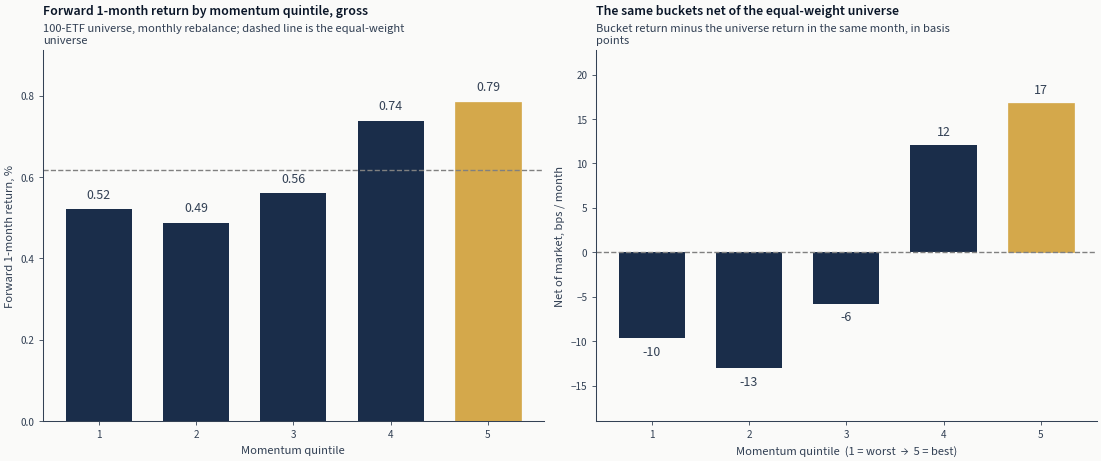

In [7]:
fig, (axg, axn) = plt.subplots(1, 2, figsize=(11, 4.6))
labels = [str(q) for q in qs]

bg = axg.bar(labels, gross, color=COLORS["slate"], width=0.68)
bg[-1].set_color(COLORS["amber"])
axg.axhline(bench_pct, ls="--", lw=1, color="grey")
add_message_title(
    axg,
    "Forward 1-month return by momentum quintile, gross",
    subtitle="100-ETF universe, monthly rebalance; dashed line is the equal-weight universe",
)
axg.set_xlabel("Momentum quintile")
axg.set_ylabel("Forward 1-month return, %")
for x, v in zip(labels, gross):
    axg.text(x, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
axg.margins(y=0.16)

bn = axn.bar(labels, net_bps, color=COLORS["slate"], width=0.68)
bn[-1].set_color(COLORS["amber"])
axn.axhline(0, ls="--", lw=1, color="grey")
add_message_title(
    axn,
    "The same buckets net of the equal-weight universe",
    subtitle="Bucket return minus the universe return in the same month, in basis points",
)
axn.set_xlabel("Momentum quintile  (1 = worst  →  5 = best)")
axn.set_ylabel("Net of market, bps / month")
for x, v in zip(labels, net_bps):
    axn.text(
        x,
        v + (0.8 if v >= 0 else -0.8),
        f"{v:.0f}",
        ha="center",
        va="bottom" if v >= 0 else "top",
        fontsize=10,
    )
axn.margins(y=0.20)
show_with_alt(
    fig,
    "Two bar panels over the five momentum quintiles. The left panel plots each "
    "bucket's gross forward 1-month return in percent against a dashed line at the "
    "equal-weight universe return; the right panel plots the same buckets net of that "
    "universe, in basis points, against a dashed zero line. The top quintile is "
    "highlighted in amber in both panels and every bar is labelled with its value.",
)

**Read it.** Gross, all five buckets sit close together and close to the dashed
benchmark line: most of what they earn is beta, the return for being invested at all
while the universe drifted up. The right panel takes the universe out and leaves the
*tilt*: the lower buckets net negative, the upper ones net positive, ordering roughly
with past momentum. The printed table above carries the levels; what the figure is for
is the ordering and the size of the gaps against the benchmark. The top-minus-bottom
spread is identical gross or net, because the benchmark cancels, and the long-short
t-statistic is printed beside it - read it before reading the spread. On the full
sample the footprint is there and it is small, and one average over two decades can
hide a lot, so the next section cuts the sample by era.

## 4. Is it lumpy but present, or an artifact? Split by era

A real mechanism is usually *lumpy but present*: still there when the sample is cut
by time, even if it is not equally strong everywhere. An effect that lives entirely in
one period is telling you what it actually is. We split the sample in half and rerun
the sort. Recall the mechanism's own warning: information-based edges **decay** as
everyone learns to read the same price history.

In [8]:
wide_era = wide.with_columns(
    era=pl.when(pl.col("timestamp") < pl.date(2016, 1, 1))
    .then(pl.lit("2006–2015"))
    .otherwise(pl.lit("2016–2025"))
)
rows = []
for era in ["2006–2015", "2016–2025"]:
    e = wide_era.filter(pl.col("era") == era)
    q1 = (e["1"] - e["bench"]).mean() * 1e4
    q5 = (e["5"] - e["bench"]).mean() * 1e4
    ls_e = (e["5"] - e["1"]).drop_nulls()
    rows.append(
        {
            "era": era,
            "Q1_net_bps": round(q1),
            "Q5_net_bps": round(q5),
            "spread_bps": round(q5 - q1),
            "ls_t": round(ls_e.mean() / ls_e.std() * np.sqrt(ls_e.len()), 2),
            "months": e.height,
        }
    )
era_tbl = pl.DataFrame(rows)
print(era_tbl)

shape: (2, 6)
┌───────────┬────────────┬────────────┬────────────┬──────┬────────┐
│ era       ┆ Q1_net_bps ┆ Q5_net_bps ┆ spread_bps ┆ ls_t ┆ months │
│ ---       ┆ ---        ┆ ---        ┆ ---        ┆ ---  ┆ ---    │
│ str       ┆ i64        ┆ i64        ┆ i64        ┆ f64  ┆ i64    │
╞═══════════╪════════════╪════════════╪════════════╪══════╪════════╡
│ 2006–2015 ┆ -26        ┆ 19         ┆ 45         ┆ 0.92 ┆ 108    │
│ 2016–2025 ┆ 5          ┆ 14         ┆ 9          ┆ 0.28 ┆ 119    │
└───────────┴────────────┴────────────┴────────────┴──────┴────────┘


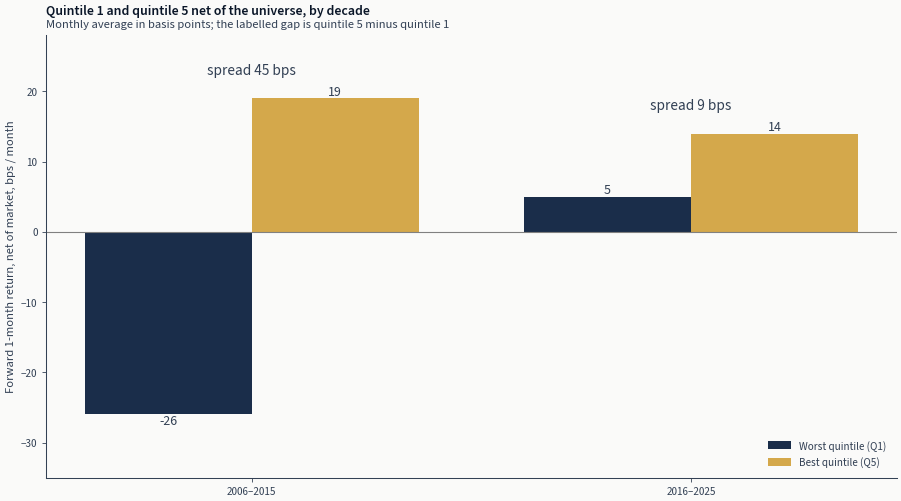

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
eras = era_tbl["era"].to_list()
q1_bps, q5_bps, spreads = (
    era_tbl["Q1_net_bps"].to_list(),
    era_tbl["Q5_net_bps"].to_list(),
    era_tbl["spread_bps"].to_list(),
)
x = np.arange(len(eras))
w = 0.38
ax.bar(x - w / 2, q1_bps, w, label="Worst quintile (Q1)", color=COLORS["slate"])
ax.bar(x + w / 2, q5_bps, w, label="Best quintile (Q5)", color=COLORS["amber"])
for xi, (q1, q5, sp) in enumerate(zip(q1_bps, q5_bps, spreads)):
    ax.text(
        xi - w / 2, q1, f"{q1:.0f}", ha="center", va="bottom" if q1 >= 0 else "top", fontsize=10
    )
    ax.text(
        xi + w / 2, q5, f"{q5:.0f}", ha="center", va="bottom" if q5 >= 0 else "top", fontsize=10
    )
    ax.text(xi, max(q1, q5) + 3, f"spread {sp:.0f} bps", ha="center", va="bottom", fontsize=11)
ax.axhline(0, lw=0.8, color="grey")
ax.set_xticks(x)
ax.set_xticklabels(eras)
ax.set_ylabel("Forward 1-month return, net of market, bps / month")
add_message_title(
    ax,
    "Quintile 1 and quintile 5 net of the universe, by decade",
    subtitle="Monthly average in basis points; the labelled gap is quintile 5 minus quintile 1",
)
ax.legend(frameon=False, loc="lower right")
ax.margins(y=0.2)
show_with_alt(
    fig,
    "A grouped bar chart with one pair of bars per decade: the worst momentum quintile "
    "in slate and the best in amber, each plotted as its monthly average net of the "
    "equal-weight universe in basis points, against a zero line. Every bar is labelled "
    "with its value and the quintile 5 minus quintile 1 gap is annotated above each pair.",
)

**Read it.** Net of the market, the gap between the top and bottom quintile is wide
in the first decade and much narrower in the second; both spreads are in the printed
table. An information-based edge fading as it becomes widely known is one reading of
that, and it is the reading the mechanism named at the top of the notebook predicts.
Two things keep it at suggestive rather than shown: the tradable long-short is not
statistically significant in either era, which the `ls_t` column reports, and a
two-bucket split is itself a coarse cut. The exercises move the boundary and ask how
stable the fade is.

## 5. One feasibility check: how fast does the signal turn over?

Costs are decided by turnover, and turnover is governed by how much the ranking
changes month to month. We measure the month-over-month rank autocorrelation of
the signal: a high autocorrelation means this month's ranking is largely last month's
ranking, so we trade little.

The Spearman rank correlation is the Pearson correlation of the ranks. Each pair of
adjacent months is joined on the symbols present in both, kept only where at least
`MIN_NAMES` symbols survive the join, and the per-pair correlations are averaged.

In [10]:
mom = monthly.select("timestamp", "symbol", "momentum").drop_nulls("momentum")
months = mom["timestamp"].unique().sort().to_list()
month_index = {t: i for i, t in enumerate(months)}
mom = mom.with_columns(mi=pl.col("timestamp").replace_strict(month_index, return_dtype=pl.Int32))
this_month = mom.select("symbol", "momentum", "mi")
prev_month = mom.select(
    "symbol", pl.col("momentum").alias("mom_prev"), (pl.col("mi") + 1).alias("mi")
)
pairs = (
    this_month.join(prev_month, on=["symbol", "mi"])
    .filter(pl.len().over("mi") >= MIN_NAMES)
    .with_columns(
        r_curr=pl.col("momentum").rank("average").over("mi"),
        r_prev=pl.col("mom_prev").rank("average").over("mi"),
    )
)
autocorr = pairs.group_by("mi").agg(rho=pl.corr("r_curr", "r_prev"))["rho"].mean()
print(f"Mean month-over-month rank autocorrelation: {autocorr:.3f}")
print("(High → the ranking is persistent → turnover and costs are modest.)")

Mean month-over-month rank autocorrelation: 0.894
(High → the ranking is persistent → turnover and costs are modest.)


## 6. What the EDA established, and what comes next

What it established, and what it did **not**:

- Net of the market, the mechanism leaves a **top-concentrated** tilt: enough to be
  worth engineering, not enough to trade on its own. The tradable long-short is
  **not statistically significant** at the t-statistic printed above, and all of this
  is **before costs**.
- It is **regime-dependent**: the spread is much narrower in the second decade than
  in the first. Evaluation must respect *when* the edge lived, which is why we
  validate **walk-forward** rather than on a shuffled or full-sample average.
- The signal is **persistent**, at the rank autocorrelation printed above, so
  turnover is low and costs are unlikely to erase the tilt outright. We have still
  not subtracted a single basis point.

Nothing here is a backtest. It is visual confirmation that there is *something* to
model, plus a set of cautions. The rest of the chapter turns this into a disciplined
evaluation: **freeze the setup** (§6.3), **validate it walk-forward without leakage**
(§6.5), and keep the search **countable and auditable** (§6.7). Chapter 7 then
defines a **tradable label** and accounts for **overlap and effective sample size**
before trusting any significance.